In [ ]:
import pandas as pd
df=pd.read_csv('/content/load_forecasting_processed (1).csv')
df.head()

,Timestamp,Total_Load_kWh,hour,minute,day_of_week,day_of_month,month,day_of_year,is_weekend,morning_peak,...,lag_2,lag_4,lag_48,lag_96,lag_336,rolling_mean_2,rolling_mean_4,rolling_mean_48,rolling_std_48,target
0,2012-07-08 00:00:00,178.265,0,0,6,8,7,190,1,0,...,168.378,191.208,198.315,205.729,189.320,168.5185,179.65575,155.362979,46.054631,213.914
1,2012-07-08 00:30:00,213.914,0,30,6,8,7,190,1,0,...,168.659,190.378,214.829,202.873,178.035,173.4620,176.42000,154.945271,45.746669,184.223
2,2012-07-08 01:00:00,184.223,1,0,6,8,7,190,1,0,...,178.265,168.378,190.810,178.253,155.212,196.0895,182.30400,154.926208,45.721369,171.707
3,2012-07-08 01:30:00,171.707,1,30,6,8,7,190,1,0,...,213.914,168.659,166.140,169.731,148.907,199.0685,186.26525,154.788979,45.621150,142.249
4,2012-07-08 02:00:00,142.249,2,0,6,8,7,190,1,0,...,184.223,178.265,142.278,144.979,123.750,177.9650,187.02725,154.904958,45.657682,118.174


In [ ]:
# Target column
target_col = "target"

# Columns that should NOT be used as model features
exclude_cols = [
    "Timestamp",
    "Total_Load_kWh",
    "target"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

X = df[feature_cols]
y = df[target_col]

print("Number of features:", len(feature_cols))
print("\nFeatures:")
print(feature_cols)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of features: 23

Features:
['hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'is_weekend', 'morning_peak', 'evening_peak', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_4', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_2', 'rolling_mean_4', 'rolling_mean_48', 'rolling_std_48']

X shape: (17183, 23)
y shape: (17183,)


In [ ]:
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("===== DATASET SIZES ===")
print("Total:", n)
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

===== DATASET SIZES ===
Total: 17183
Train: 12028
Validation: 2577
Test: 2578


In [ ]:
print("===== DATE RANGES ====")

print(
    "Train:",
    df["Timestamp"].iloc[0],
    "→",
    df["Timestamp"].iloc[train_end - 1]
)

print(
    "Validation:",
    df["Timestamp"].iloc[train_end],
    "→",
    df["Timestamp"].iloc[val_end - 1]
)

print(
    "Test:",
    df["Timestamp"].iloc[val_end],
    "→",
    df["Timestamp"].iloc[-1]
)

===== DATE RANGES ====
Train: 2012-07-08 00:00:00 → 2013-03-15 13:30:00
Validation: 2013-03-15 14:00:00 → 2013-05-08 06:00:00
Test: 2013-05-08 06:30:00 → 2013-06-30 23:00:00


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Persistence prediction on test set
persistence_pred = (
    df["Total_Load_kWh"]
    .iloc[val_end:]
    .values
)

actual_test = y_test.values

persistence_mae = mean_absolute_error(
    actual_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        persistence_pred
    )
)

persistence_r2 = r2_score(
    actual_test,
    persistence_pred
)

print("===== PERSISTENCE BASELINE =====")
print("MAE :", persistence_mae)
print("RMSE:", persistence_rmse)
print("R²  :", persistence_r2)

===== PERSISTENCE BASELINE =====
MAE : 10.694632273079906
RMSE: 14.10090178935659
R²  : 0.892589622673233


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

val_pred = model.predict(X_val)

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_r2 = r2_score(y_val, val_pred)

print("===== XGBOOST VALIDATION RESULTS =====")
print("MAE :", val_mae)
print("RMSE:", val_rmse)
print("R²  :", val_r2)

===== XGBOOST VALIDATION RESULTS =====
MAE : 6.160294249623795
RMSE: 8.406869053962625
R²  : 0.8926749826369974


In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("===== TOP 15 FEATURES =====")
print(importance_df.head(15))

===== TOP 15 FEATURES =====
            Feature  Importance
0             lag_1    0.405506
1    rolling_mean_2    0.201925
2           lag_336    0.083153
3            lag_48    0.062102
4          hour_sin    0.045847
5          hour_cos    0.033781
6              hour    0.030760
7   day_of_year_cos    0.027316
8             month    0.015393
9      evening_peak    0.014584
10       is_weekend    0.011349
11            lag_2    0.010920
12  rolling_mean_48    0.007782
13     morning_peak    0.007450
14            lag_4    0.007215


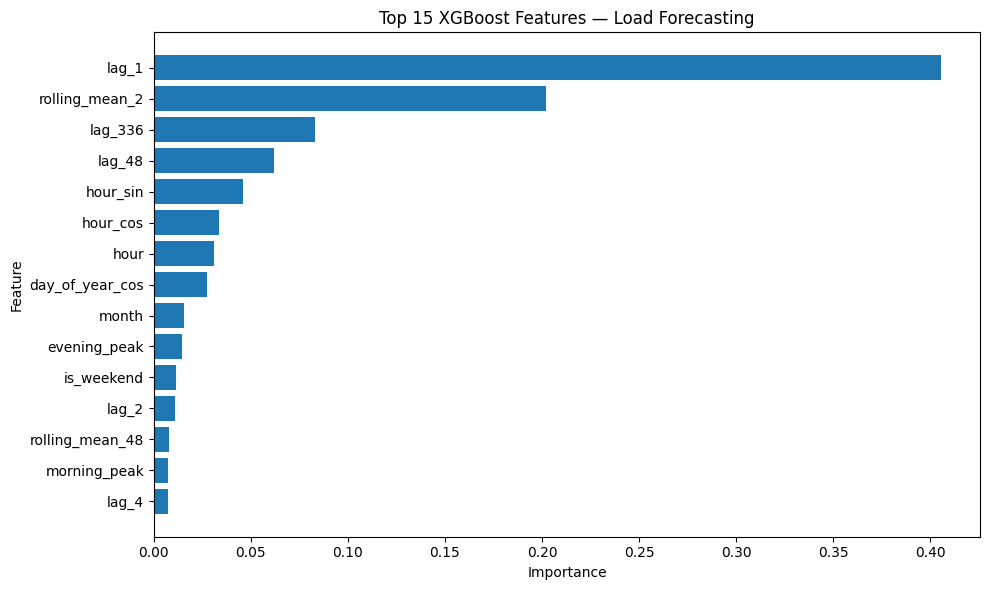

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features — Load Forecasting")
plt.tight_layout()
plt.show()

In [ ]:
test_pred = model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print("===== XGBOOST TEST RESULTS =====")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

===== XGBOOST TEST RESULTS =====
MAE : 7.571768159604424
RMSE: 9.970813644295689
R²  : 0.9462951305431688


In [ ]:
print("\n===== FINAL COMPARISON =====")

print("Persistence MAE :", persistence_mae)
print("XGBoost MAE     :", test_mae)

print("Persistence RMSE:", persistence_rmse)
print("XGBoost RMSE    :", test_rmse)

print("Persistence R²  :", persistence_r2)
print("XGBoost R²      :", test_r2)


===== FINAL COMPARISON =====
Persistence MAE : 10.694632273079906
XGBoost MAE     : 7.571768159604424
Persistence RMSE: 14.10090178935659
XGBoost RMSE    : 9.970813644295689
Persistence R²  : 0.892589622673233
XGBoost R²      : 0.9462951305431688


In [ ]:
import joblib

joblib.dump(model, "load_xgboost_model.pkl")

print("Load XGBoost model saved successfully.")

Load XGBoost model saved successfully.


In [ ]:
joblib.dump(feature_cols, "load_feature_columns.pkl")

print("Load feature list saved successfully.")

Load feature list saved successfully.


In [ ]:
load_predictions = pd.DataFrame({
    "Timestamp": df["Timestamp"].iloc[val_end:].values,
    "Actual_Load_kWh": y_test.values,
    "Predicted_Load_kWh": test_pred
})

load_predictions.to_csv(
    "load_predictions.csv",
    index=False
)

print("Predictions saved:", load_predictions.shape)
print(load_predictions.head())

Predictions saved: (2578, 3)
             Timestamp  Actual_Load_kWh  Predicted_Load_kWh
0  2013-05-08 06:30:00          117.116          101.789803
1  2013-05-08 07:00:00          108.571          115.281265
2  2013-05-08 07:30:00          104.717          109.001038
3  2013-05-08 08:00:00          102.089           97.032143
4  2013-05-08 08:30:00           92.435           90.316566


In [ ]:
load_predictions["Error"] = (
    load_predictions["Predicted_Load_kWh"]
    - load_predictions["Actual_Load_kWh"]
)

load_predictions["Absolute_Error"] = (
    load_predictions["Error"].abs()
)

print("===== ERROR STATISTICS =====")
print(load_predictions["Error"].describe())

===== ERROR STATISTICS =====
count    2578.000000
mean       -0.802869
std         9.940365
min       -53.819664
25%        -6.241386
50%        -0.186255
75%         5.489271
max        36.828653
Name: Error, dtype: float64


In [ ]:
worst_errors = load_predictions.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

print("===== 10 WORST PREDICTIONS =====")
print(worst_errors)

===== 10 WORST PREDICTIONS =====
                Timestamp  Actual_Load_kWh  Predicted_Load_kWh      Error  \
1222  2013-06-02 17:30:00          250.695          196.875336 -53.819664   
1221  2013-06-02 17:00:00          220.356          176.344360 -44.011640   
1605  2013-06-10 17:00:00          202.730          160.145309 -42.584691   
336   2013-05-15 06:30:00          140.352          103.062988 -37.289012   
1635  2013-06-11 08:00:00          113.150          149.978653  36.828653   
2164  2013-06-22 08:30:00          190.716          156.443848 -34.272152   
418   2013-05-16 23:30:00          183.587          150.550552 -33.036448   
2255  2013-06-24 06:00:00          139.374          106.506226 -32.867774   
2331  2013-06-25 20:00:00          244.642          211.833847 -32.808153   
1559  2013-06-09 18:00:00          162.951          194.684036  31.733036   

      Absolute_Error  
1222       53.819664  
1221       44.011640  
1605       42.584691  
336        37.289012  
1635

In [ ]:
load_predictions["Timestamp"] = pd.to_datetime(load_predictions["Timestamp"])
load_predictions["Hour"] = load_predictions["Timestamp"].dt.hour

hourly_error = (
    load_predictions
    .groupby("Hour")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

print("===== MAE BY HOUR ===")
print(hourly_error)

===== MAE BY HOUR ===
Hour
23    13.493007
17    11.823106
18    11.147328
6     10.678428
8      9.902278
0      9.475077
16     9.272154
20     8.153126
19     8.061150
21     7.857517
7      7.737033
1      7.238134
10     7.208647
12     6.501257
11     6.424687
9      6.381259
15     6.285290
13     5.789309
14     5.397214
4      5.214964
2      5.071836
5      4.425655
22     4.166767
3      3.913933
Name: Absolute_Error, dtype: float64


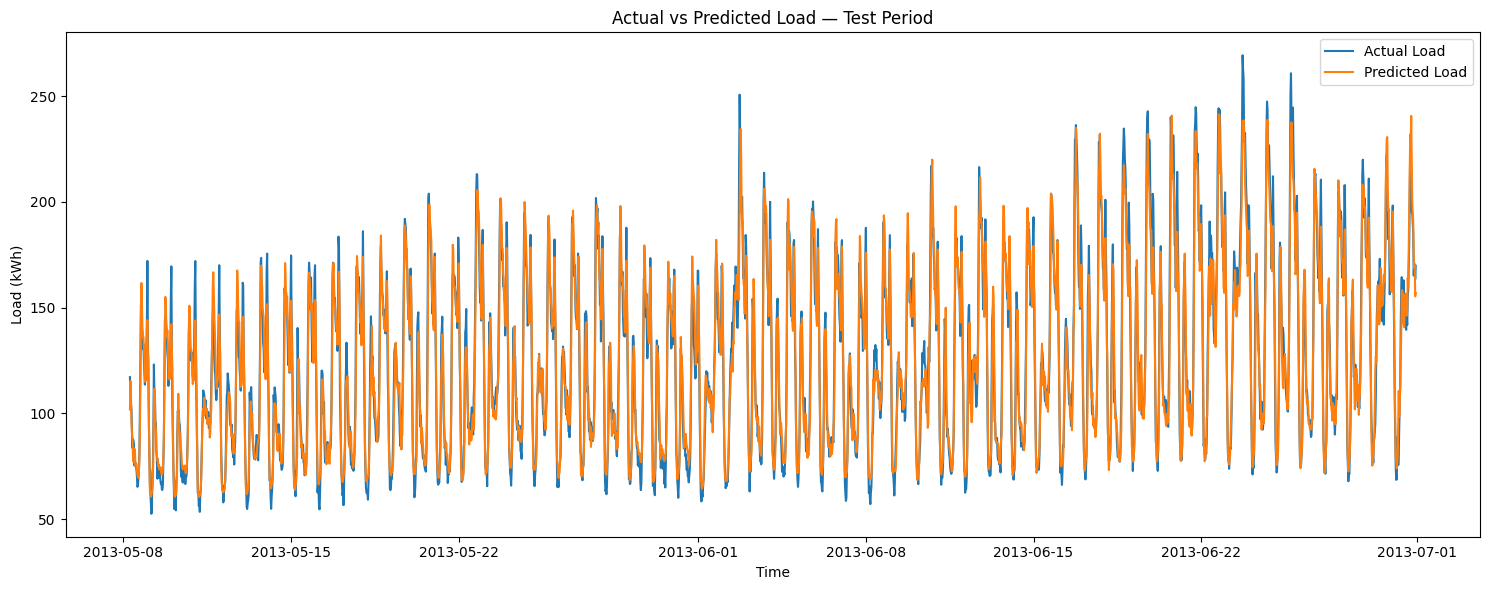

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    load_predictions["Timestamp"],
    load_predictions["Actual_Load_kWh"],
    label="Actual Load"
)

plt.plot(
    load_predictions["Timestamp"],
    load_predictions["Predicted_Load_kWh"],
    label="Predicted Load"
)

plt.xlabel("Time")
plt.ylabel("Load (kWh)")
plt.title("Actual vs Predicted Load — Test Period")
plt.legend()
plt.tight_layout()
plt.show()